<a href="https://www.kaggle.com/code/mayuringle8890/machine-learning-visualization-part-3?scriptVersionId=283079636" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 📊 Data Visualization Tutorial - Part 03: Statistical Visualizations with Seaborn

## Welcome to Part 3: Advanced Statistical Plots!

In this tutorial, we'll dive deep into **statistical visualizations** using Seaborn and Matplotlib.

### 🎯 Learning Objectives:
1. **Joint Plots**: Understand relationships between two variables with distribution context
2. **Distribution Plots**: Visualize data spread and shape
3. **Box Plots & Violin Plots**: Compare distributions across categories
4. **Heatmaps**: Visualize correlation matrices and patterns
5. **Pair Plots**: Explore multiple variable relationships simultaneously

### 📚 What You'll Learn:
- Creating and interpreting joint plots (scatter + distributions)
- Understanding different plot types for distribution analysis
- Working with correlation matrices
- Identifying outliers and patterns
- Statistical testing visualization
- Best practices for statistical graphics

### 📊 Datasets Used:
- **Heart Disease UCI Dataset**: Medical metrics and diagnoses
- **Wine Quality Dataset**: Chemical properties and quality ratings
- **Titanic Dataset**: Passenger information and survival

### 🛠️ Technologies:
- **Seaborn**: Statistical data visualization
- **Matplotlib**: Customization and fine-tuning
- **SciPy**: Statistical calculations
- **Pandas**: Data manipulation

---

Explore this multi-part series designed to help you understand and visualize data effectively.  
Each part focuses on a specific visualization category with practical examples and explanations.

---

### 🔹 **Part 01: Basic Visualizations**  
Foundational charts such as bar plots, histograms, line charts, and scatter plots to understand core data patterns.  
➡️ https://www.kaggle.com/code/mayuringle8890/machine-learning-visualization-part-1/

### 🌍 **Part 02: Geographic Visualizations**  
Visualize spatial patterns using choropleths, geospatial maps, and coordinate-based plots.  
➡️ https://www.kaggle.com/code/mayuringle8890/machine-learning-visualization-part-2/

### 📈 **Part 03: Statistical Visualizations**  
Statistical plots like KDE, boxplots, violin plots, pairplots, and heatmaps to analyze distributions and relationships.  
➡️ https://www.kaggle.com/code/mayuringle8890/machine-learning-visualization-part-3/

### 🧊 **Part 04: 3D Visualizations**  
Use 3D scatter, surface, contour, and wireframe plots to explore multi-dimensional data visually.  
➡️ https://www.kaggle.com/code/mayuringle8890/machine-learning-visualization-part-4/

### 🕳️ **Part 05: Missing Data Visualization**  
Identify missing data patterns using heatmaps, matrices, and summary charts for better data preprocessing.  
➡️ https://www.kaggle.com/code/mayuringle8890/machine-learning-visualization-part-5/


## 1️⃣ Environment Setup

Let's import all necessary libraries and configure our visualization environment.

In [1]:
# Core libraries
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

# Statistical tools
import scipy.stats as stats
from scipy.stats import norm

# Display settings
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")
print(f"Seaborn version: {sns.__version__}")
print(f"Pandas version: {pd.__version__}")

✅ All libraries loaded successfully!
Seaborn version: 0.12.2
Pandas version: 2.2.3


## 2️⃣ Loading the Heart Disease Dataset

### About the Dataset

The UCI Heart Disease dataset is one of the most popular datasets for classification tasks.
It contains various medical measurements that can indicate heart disease risk.

**Key Variables:**
- **chol**: Cholesterol level (mg/dl)
- **thalch**: Maximum heart rate achieved
- **trestbps**: Resting blood pressure
- **age**: Patient age
- **num**: Heart disease diagnosis (0 = no disease, 1-4 = disease present)

In [2]:
# Load the dataset
df = pd.read_csv("/kaggle/input/heart-disease-data/heart_disease_uci.csv")

# Clean the data
df = df.dropna()

# Display basic information
print(f"📊 Dataset Shape: {df.shape}")
print(f"\n📋 Columns: {list(df.columns)}")
print(f"\n🔍 Missing values: {df.isnull().sum().sum()}")
print("\nFirst few rows:")
df.head()

📊 Dataset Shape: (299, 16)

📋 Columns: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

🔍 Missing values: 0

First few rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 3️⃣ Joint Plots: The Power of Combined Views

### What is a Joint Plot?

A **joint plot** combines three plots in one figure:
1. **Central scatter plot**: Shows the relationship between two variables
2. **Top histogram**: Shows distribution of X variable
3. **Right histogram**: Shows distribution of Y variable

### Why Use Joint Plots?

Joint plots are powerful because they show:
- **Correlation**: How variables relate to each other
- **Distribution**: How each variable is spread
- **Outliers**: Unusual data points
- **Patterns**: Clusters or trends

### Types of Joint Plots:
- **'scatter'**: Traditional scatter plot (default)
- **'kde'**: Kernel density estimate (smooth contours)
- **'hex'**: Hexagonal binning (good for large datasets)
- **'reg'**: Regression line with scatter
- **'resid'**: Residual plot for regression

Creating joint plot: Cholesterol vs Max Heart Rate



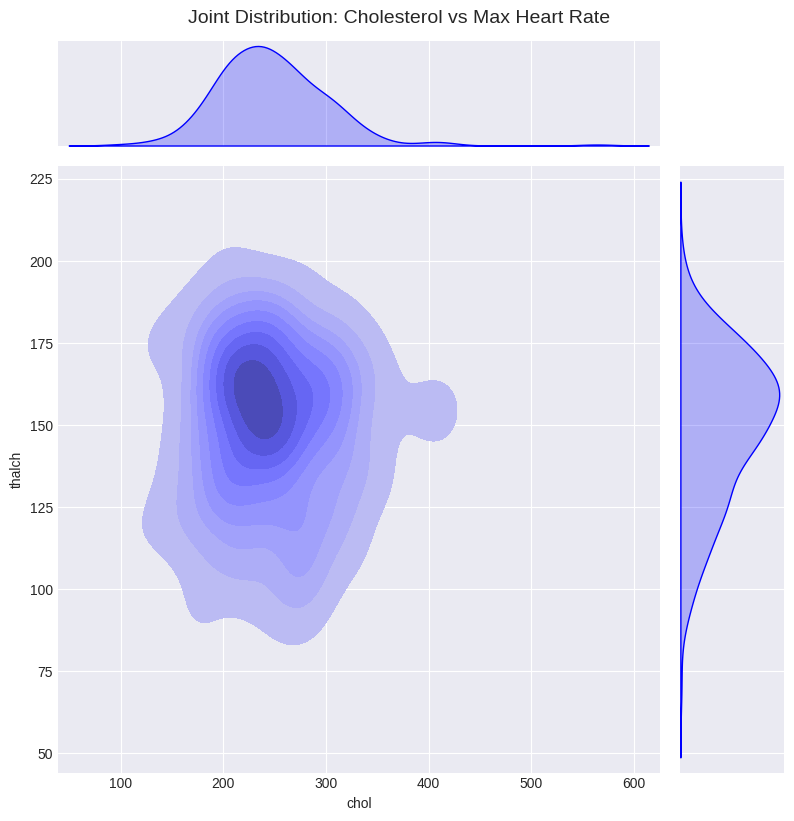


📊 How to Read This Plot:
- Darker areas = Higher concentration of data points
- Top plot = Distribution of cholesterol levels
- Right plot = Distribution of max heart rates
- Center = Relationship between the two variables


In [3]:
# Create a KDE joint plot
print("Creating joint plot: Cholesterol vs Max Heart Rate\n")

g = sns.jointplot(
    x="chol",  # Cholesterol on X-axis
    y="thalch",  # Max heart rate on Y-axis
    data=df,
    kind="kde",  # Kernel Density Estimate
    color="b",
    fill=True,  # Fill the contours
    height=8
)

# Add title
g.fig.suptitle('Joint Distribution: Cholesterol vs Max Heart Rate', 
               fontsize=14, y=1.02)

plt.show()

print("\n📊 How to Read This Plot:")
print("- Darker areas = Higher concentration of data points")
print("- Top plot = Distribution of cholesterol levels")
print("- Right plot = Distribution of max heart rates")
print("- Center = Relationship between the two variables")

## 4️⃣ Scatter Joint Plot with Regression

### Understanding Regression Lines

A **regression line** shows the general trend in the relationship between two variables.
- **Positive slope**: As X increases, Y tends to increase
- **Negative slope**: As X increases, Y tends to decrease
- **Flat line**: Little to no relationship

### Interpreting Scatter Plots:
- **Tight clustering around line**: Strong relationship
- **Wide spread**: Weak relationship
- **Outliers**: Points far from the pattern

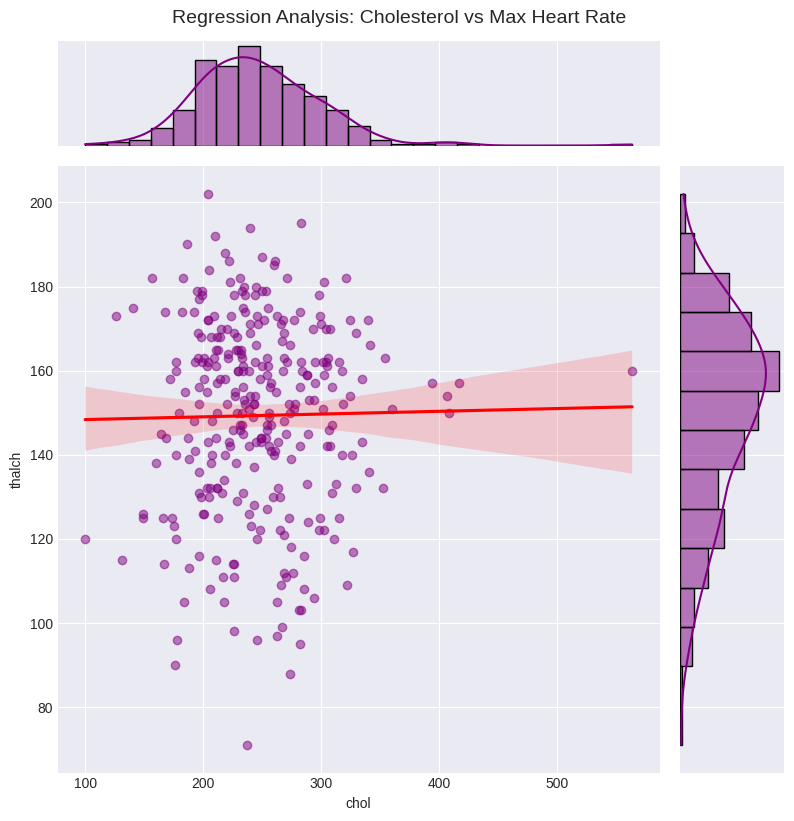


🔍 Interpretation:
- The regression line shows the average relationship
- Shaded area = Confidence interval (uncertainty range)
- Points above line = Higher heart rate than expected
- Points below line = Lower heart rate than expected


In [4]:
# Create scatter plot with regression line
g2 = sns.jointplot(
    x="chol",
    y="thalch",
    data=df,
    kind="reg",  # Regression plot
    color="purple",
    height=8,
    scatter_kws={'alpha': 0.5},  # Semi-transparent points
    line_kws={'color': 'red'}  # Red regression line
)

g2.fig.suptitle('Regression Analysis: Cholesterol vs Max Heart Rate',
                fontsize=14, y=1.02)

plt.show()

print("\n🔍 Interpretation:")
print("- The regression line shows the average relationship")
print("- Shaded area = Confidence interval (uncertainty range)")
print("- Points above line = Higher heart rate than expected")
print("- Points below line = Lower heart rate than expected")

## 5️⃣ Distribution Plots: Understanding Data Shape

### Types of Distribution Plots:

1. **Histogram**: Bars showing frequency in bins
2. **KDE Plot**: Smooth curve showing probability density
3. **Rug Plot**: Small ticks showing individual data points

### What to Look For:
- **Central Tendency**: Where most data clusters (mean, median)
- **Spread**: How wide the distribution is (variance)
- **Skewness**: Is it symmetric or leaning to one side?
- **Modality**: One peak (unimodal) or multiple peaks (bimodal)?
- **Outliers**: Extreme values far from the center

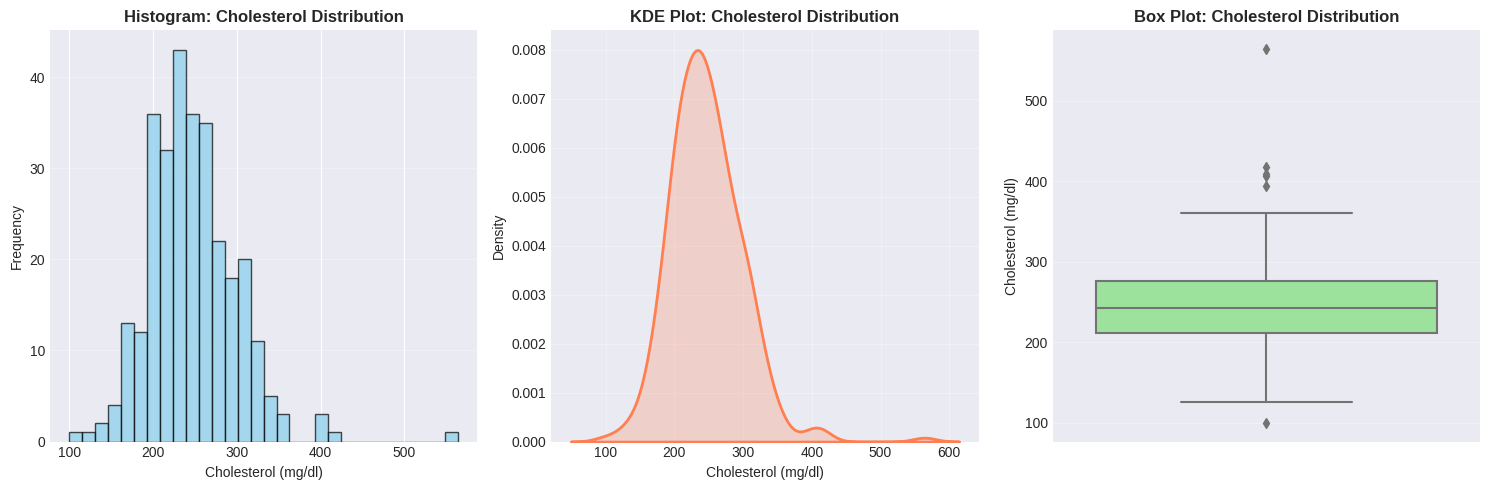


📊 Cholesterol Statistics:
Mean: 246.79 mg/dl
Median: 242.00 mg/dl
Std Dev: 52.53 mg/dl
Min: 100.00 mg/dl
Max: 564.00 mg/dl


In [5]:
# Create figure with multiple distribution plots
plt.figure(figsize=(15, 5))

# Histogram
plt.subplot(1, 3, 1)
plt.hist(df['chol'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Histogram: Cholesterol Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Cholesterol (mg/dl)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

# KDE Plot
plt.subplot(1, 3, 2)
sns.kdeplot(data=df['chol'], fill=True, color='coral', linewidth=2)
plt.title('KDE Plot: Cholesterol Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Cholesterol (mg/dl)')
plt.ylabel('Density')
plt.grid(alpha=0.3)

# Box Plot
plt.subplot(1, 3, 3)
sns.boxplot(y=df['chol'], color='lightgreen')
plt.title('Box Plot: Cholesterol Distribution', fontsize=12, fontweight='bold')
plt.ylabel('Cholesterol (mg/dl)')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\n📊 Cholesterol Statistics:")
print(f"Mean: {df['chol'].mean():.2f} mg/dl")
print(f"Median: {df['chol'].median():.2f} mg/dl")
print(f"Std Dev: {df['chol'].std():.2f} mg/dl")
print(f"Min: {df['chol'].min():.2f} mg/dl")
print(f"Max: {df['chol'].max():.2f} mg/dl")